# PROJECT - Manufacturing Quality Control & Predictive Maintenance

# Business Analysis

## Objective

The objective of this notebook is to transform the cleaned manufacturing data into meaningful business insights using SQL and Python. The analysis focuses on evaluating production performance, product quality, machine efficiency, predictive maintenance, supplier performance, and operator productivity. By answering real-world business questions, this notebook aims to identify operational inefficiencies, detect quality issues, uncover failure patterns, and provide data-driven recommendations that support better manufacturing decisions and continuous process improvement.

---


In [2]:
# Import essential libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sqlalchemy import create_engine
from urllib.parse import quote_plus 
import matplotlib.ticker as mtick

In [3]:
username = "root"
password = quote_plus("gunnugarg@2004")
host = "127.0.0.1"
port = 3306
database = "manufacturing_analytics"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"  
)

print("Connected Successfully")

Connected Successfully


In [4]:
pd.read_sql("SHOW TABLES;", engine)

,Tables_in_manufacturing_analytics
0,downtime_events
1,factories
2,failure_events
3,machines
4,maintenance_work_orders
5,operators
6,production_batches
7,production_lines
8,products
9,quality_inspections


In [5]:
query = """
SELECT * FROM production_batches
LIMIT 10;"""

pd.read_sql(query,engine)

,batch_id,machine_id,line_id,factory_id,product_id,supplier_id,operator_id,production_date,start_time,shift,...,scrap_units,rework_units,runtime_hours,downtime_hours,availability_ratio,actual_cycle_time_minutes,energy_consumption_kwh,scrap_cost_inr,batch_status,failure_near_batch
0,BAT000001,MCH0401,LIN015,FAC005,PRD0001,SUP0143,OPR0965,2024-01-25,12:27:27,Morning,...,18,34,5.00,1.37,0.7849,0.244,822.84,80950.93,Below Plan,0
1,BAT000002,MCH0394,LIN001,FAC001,PRD0123,SUP0009,OPR0886,2024-10-03,11:50:12,Evening,...,25,21,4.86,0.56,0.8967,0.561,627.55,6867.73,Completed,0
2,BAT000003,MCH0359,LIN019,FAC007,PRD0096,SUP0028,OPR0275,2023-12-15,00:59:23,Night,...,13,9,10.83,1.61,0.8706,2.354,821.55,29021.40,Below Plan,0
3,BAT000004,MCH0265,LIN011,FAC004,PRD0136,SUP0004,OPR0013,2023-06-24,10:32:47,Morning,...,53,57,8.85,0.22,0.9757,0.316,882.79,49370.78,Completed,0
4,BAT000005,MCH0480,LIN019,FAC007,PRD0135,SUP0043,OPR0220,2025-05-31,08:17:38,Night,...,83,60,8.19,0.66,0.9254,0.270,905.00,263690.01,Completed,0
5,BAT000006,MCH0171,LIN006,FAC002,PRD0125,SUP0162,OPR0129,2023-06-04,04:20:34,Morning,...,3,6,7.56,1.21,0.8620,1.387,1661.68,10941.54,Below Plan,0
6,BAT000007,MCH0507,LIN006,FAC002,PRD0099,SUP0113,OPR0776,2025-04-21,11:54:19,Evening,...,51,46,7.94,0.75,0.9137,0.351,1373.79,42841.22,Below Plan,0
7,BAT000008,MCH0584,LIN009,FAC003,PRD0079,SUP0023,OPR0999,2025-07-17,16:51:33,Evening,...,62,47,5.61,1.07,0.8398,0.245,557.47,330420.09,Below Plan,0
8,BAT000009,MCH0599,LIN003,FAC001,PRD0060,SUP0033,OPR0681,2024-10-15,18:31:13,Evening,...,85,64,4.71,0.72,0.8674,0.133,935.74,96827.91,Below Plan,0
9,BAT000010,MCH0413,LIN022,FAC008,PRD0147,SUP0113,OPR0685,2024-01-26,15:22:00,Morning,...,26,43,5.93,0.66,0.8998,0.235,932.21,19190.18,Below Plan,0


In [6]:
query = """
SELECT COUNT(machine_id) AS Total_Machines FROM machines;"""

pd.read_sql(query,engine)

,Total_Machines
0,600


In [7]:
query = """
SELECT
    factory_id,
    SUM(units_produced) AS total_units_produced
FROM production_batches
GROUP BY factory_id
ORDER BY total_units_produced DESC;
"""

factory_production = pd.read_sql(query, engine)

factory_production

,factory_id,total_units_produced
0,FAC002,9877149.0
1,FAC003,9635654.0
2,FAC005,9119348.0
3,FAC001,9118038.0
4,FAC008,8746227.0
5,FAC010,8537025.0
6,FAC009,8469219.0
7,FAC004,8299763.0
8,FAC007,7830237.0
9,FAC006,7464300.0


C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\1828970627.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


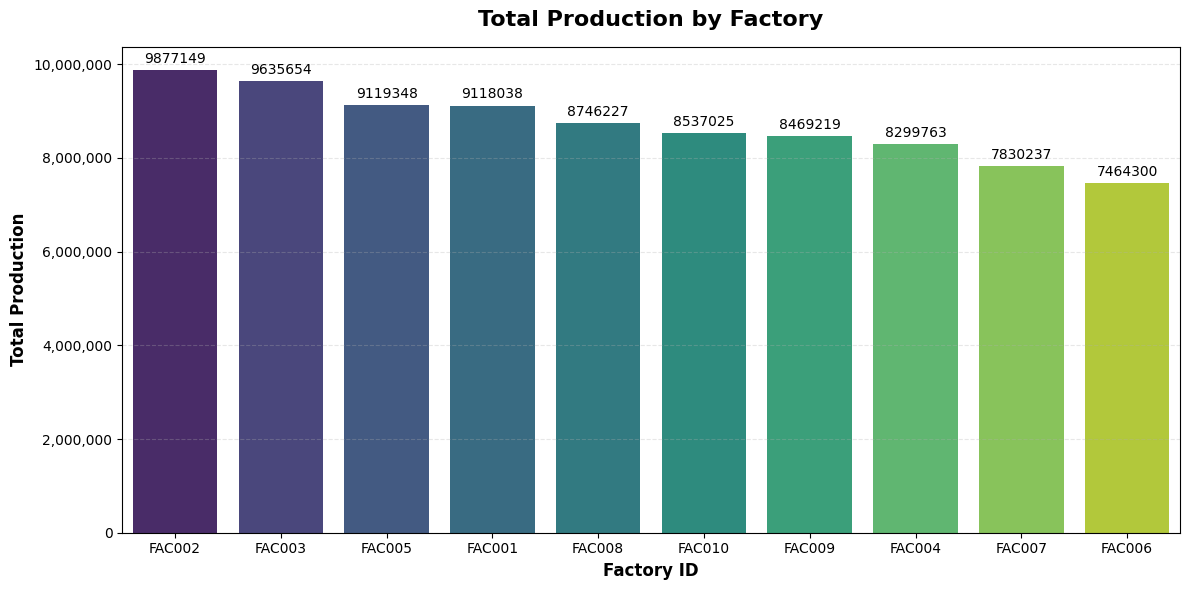

In [8]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=factory_production,
    x="factory_id",
    y="total_units_produced",
    palette="viridis"
)

ax.set_title(
    "Total Production by Factory",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Factory ID",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Total Production",
    fontsize=12,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=10
    )

    ax = plt.gca()
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
query = """
SELECT
    factory_id,
    COUNT(machine_id) AS Total_Machines
FROM machines 
GROUP BY factory_id
ORDER BY Total_Machines DESC;
"""
Factory_production = pd.read_sql(query, engine)
Factory_production


,factory_id,Total_Machines
0,FAC002,69
1,FAC003,65
2,FAC005,63
3,FAC001,63
4,FAC009,59
5,FAC010,59
6,FAC008,59
7,FAC004,58
8,FAC007,54
9,FAC006,51


C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\1992698601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


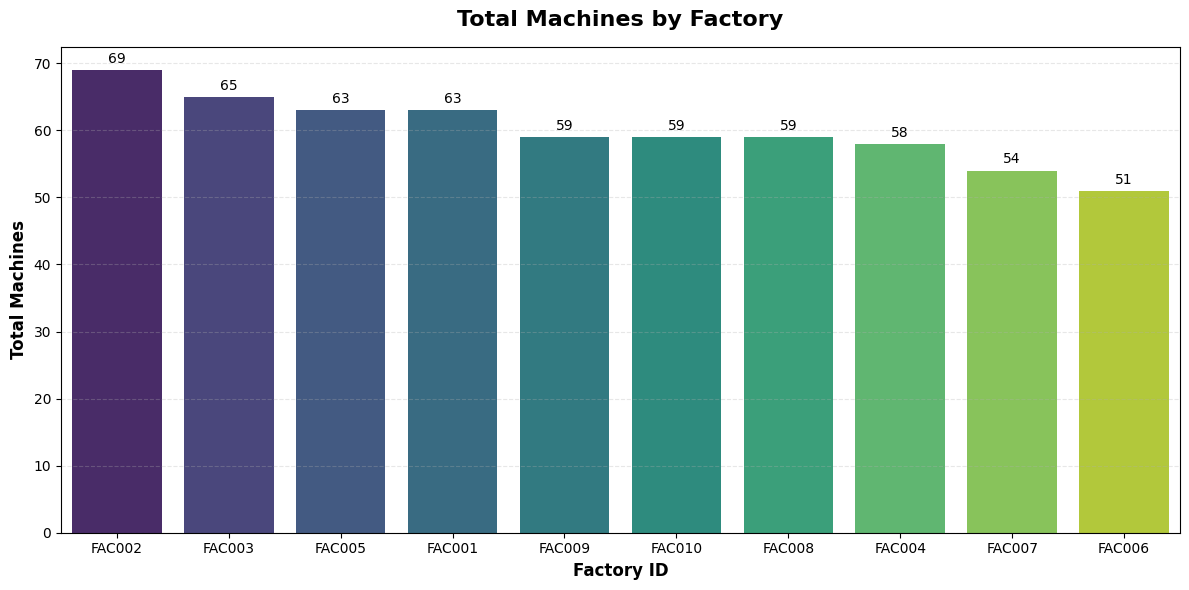

In [10]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=Factory_production,
    x="factory_id",
    y="Total_Machines",
    palette="viridis"
)

ax.set_title(
    "Total Machines by Factory",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Factory ID",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Total Machines",
    fontsize=12,
    fontweight="bold"
)

# Show values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
pd.read_sql("DESCRIBE factories ;",engine)

,Field,Type,Null,Key,Default,Extra
0,factory_id,text,YES,,None,
1,factory_name,text,YES,,None,
2,city,text,YES,,None,
3,state,text,YES,,None,
4,region,text,YES,,None,
5,specialization,text,YES,,None,
6,employee_count,bigint,YES,,None,
7,target_oee,double,YES,,None,
8,certification,text,YES,,None,


In [12]:
pd.read_sql("DESCRIBE failure_events ;", engine)

,Field,Type,Null,Key,Default,Extra
0,failure_event_id,text,YES,,None,
1,machine_id,text,YES,,None,
2,line_id,text,YES,,None,
3,factory_id,text,YES,,None,
4,failure_timestamp,text,YES,,None,
5,failure_mode,text,YES,,None,
6,failure_severity,text,YES,,None,
7,sensor_precursor_days,bigint,YES,,None,
8,repair_duration_hours,double,YES,,None,
9,estimated_failure_loss_inr,double,YES,,None,


In [13]:
query = """
SELECT f.factory_id ,
f.factory_name ,
COUNT(fe.failure_event_id) AS Total_Failure 
FROM factories f 
JOIN failure_events fe
ON f.factory_id = fe.factory_id 
GROUP BY f.factory_id , f.factory_name 
ORDER BY Total_Failure DESC;"""

factory_failure = pd.read_sql(query, engine)
factory_failure

,factory_id,factory_name,Total_Failure
0,FAC005,Bengaluru Manufacturing Plant,344
1,FAC002,Chennai Manufacturing Plant,334
2,FAC008,Kolkata Manufacturing Plant,326
3,FAC004,Ahmedabad Manufacturing Plant,325
4,FAC001,Pune Manufacturing Plant,320
5,FAC003,Gurugram Manufacturing Plant,311
6,FAC009,Hyderabad Manufacturing Plant,280
7,FAC010,Indore Manufacturing Plant,274
8,FAC007,Noida Manufacturing Plant,249
9,FAC006,Jamshedpur Manufacturing Plant,237


In [14]:
palette = sns.color_palette("Reds_r", len(factory_failure))

C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\1129811438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


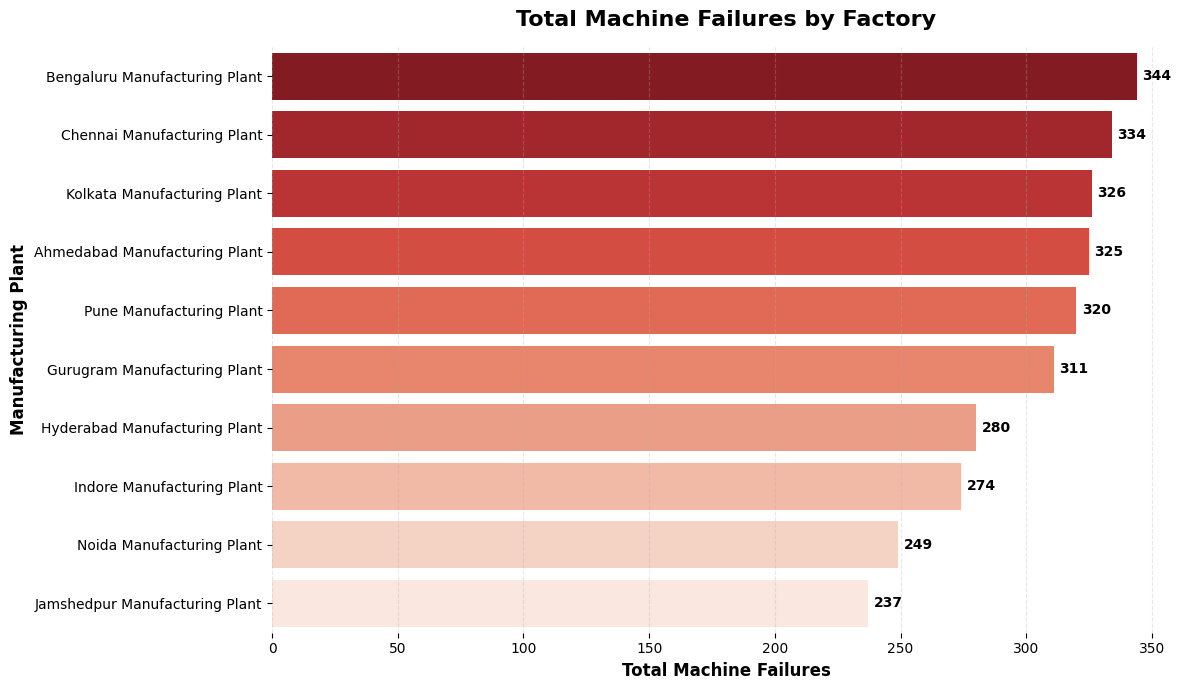

In [15]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=factory_failure,
    y="factory_name",
    x="Total_Failure",
    palette=palette
)

ax.set_title(
    "Total Machine Failures by Factory",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Total Machine Failures",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Manufacturing Plant",
    fontsize=12,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [16]:
pd.read_sql("DESCRIBE machines;", engine)

,Field,Type,Null,Key,Default,Extra
0,machine_id,text,YES,,None,
1,line_id,text,YES,,None,
2,factory_id,text,YES,,None,
3,machine_type,text,YES,,None,
4,brand,text,YES,,None,
5,model,text,YES,,None,
6,installation_date,text,YES,,None,
7,machine_age_years,double,YES,,None,
8,criticality,text,YES,,None,
9,rated_capacity_units_per_hour,bigint,YES,,None,


In [17]:
query = """
SELECT COUNT(failure_event_id) AS Total_Failure FROM failure_events"""

pd.read_sql(query,engine)

,Total_Failure
0,3000


In [18]:
query = """
SELECT
    m.machine_id,
    m.machine_type,
    m.model,
    m.machine_age_years,
    m.criticality,
    COUNT(fe.failure_event_id) AS Total_Machine_Failure
FROM machines AS m
JOIN failure_events AS fe
    ON m.machine_id = fe.machine_id
GROUP BY
    m.machine_id,
    m.machine_type,
    m.model,
    m.machine_age_years,
    m.criticality
ORDER BY Total_Machine_Failure DESC;
"""

machine_failure = pd.read_sql(query, engine)

machine_failure.head(10)

,machine_id,machine_type,model,machine_age_years,criticality,Total_Machine_Failure
0,MCH0549,CNC Lathe,DMG-287,7.2,High,12
1,MCH0120,Grinding Machine,BOS-903,15.7,High,12
2,MCH0396,Industrial Furnace,THE-344,9.5,High,11
3,MCH0133,CNC Lathe,DMG-282,6.6,High,11
4,MCH0101,Packaging Line,KRO-648,11.7,Medium,11
5,MCH0309,Hydraulic Press,SCH-542,2.4,Medium,10
6,MCH0144,Hydraulic Press,SCH-120,7.4,Critical,10
7,MCH0415,Hydraulic Press,SCH-129,3.3,High,10
8,MCH0088,Injection Molding,HUS-976,11.8,Medium,10
9,MCH0180,Industrial Furnace,THE-444,2.2,Medium,10


In [19]:
top_10_machine_failure = machine_failure.head(10).copy()

In [20]:
top_10_machine_failure["Machine"] = (
    top_10_machine_failure["machine_id"]
    + " | "
    + top_10_machine_failure["model"]
)

C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\3613689211.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


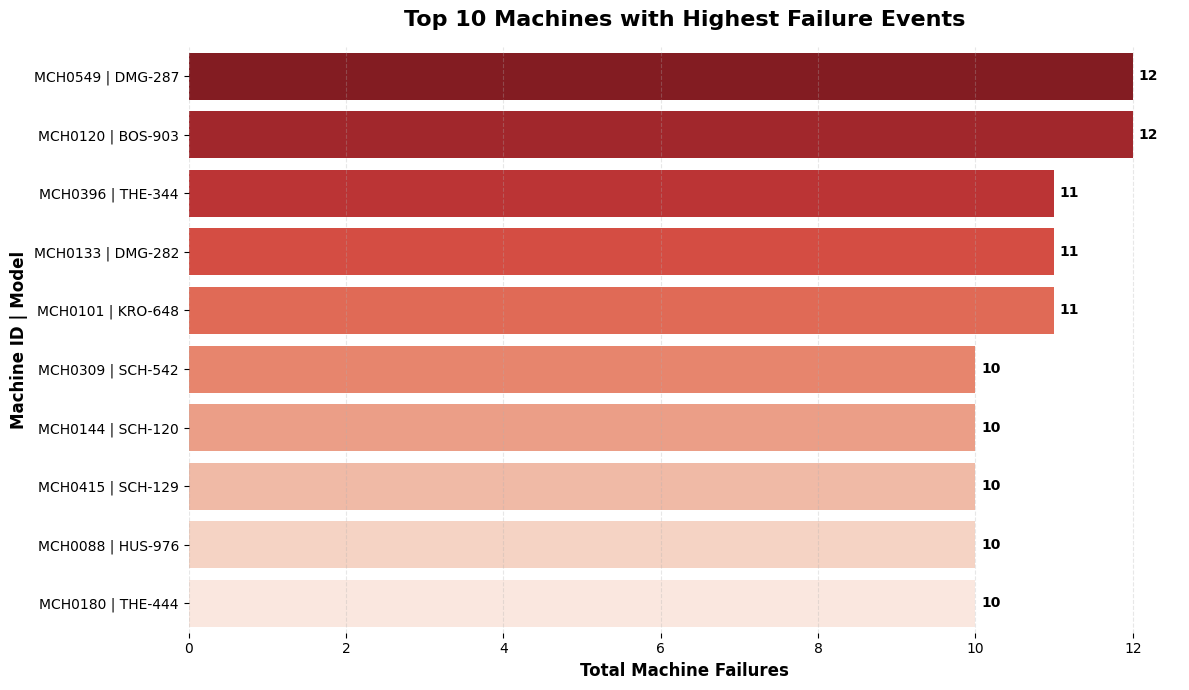

In [21]:
plt.figure(figsize=(12, 7))

colors = sns.color_palette(
    "Reds_r",
    len(top_10_machine_failure)
)

ax = sns.barplot(
    data=top_10_machine_failure,
    y="Machine",
    x="Total_Machine_Failure",
    palette=colors
)

ax.set_title(
    "Top 10 Machines with Highest Failure Events",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Total Machine Failures",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Machine ID | Model",
    fontsize=12,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

sns.despine(
    left=True,
    bottom=True
)

plt.tight_layout()
plt.show()

In [22]:
query = """
SELECT DISTINCT(m.machine_type) AS Machine_Type,
    COUNT(fe.failure_event_id) AS Total_Machine_Failure
FROM machines AS m
JOIN failure_events AS fe
    ON m.machine_id = fe.machine_id
GROUP BY Machine_Type
ORDER BY Total_Machine_Failure DESC;
"""

machine_type_failure = pd.read_sql(query, engine)

machine_type_failure

,Machine_Type,Total_Machine_Failure
0,Industrial Furnace,439
1,Packaging Line,426
2,Grinding Machine,397
3,CNC Lathe,373
4,Hydraulic Press,367
5,CNC Milling,347
6,Injection Molding,340
7,Assembly Robot,311


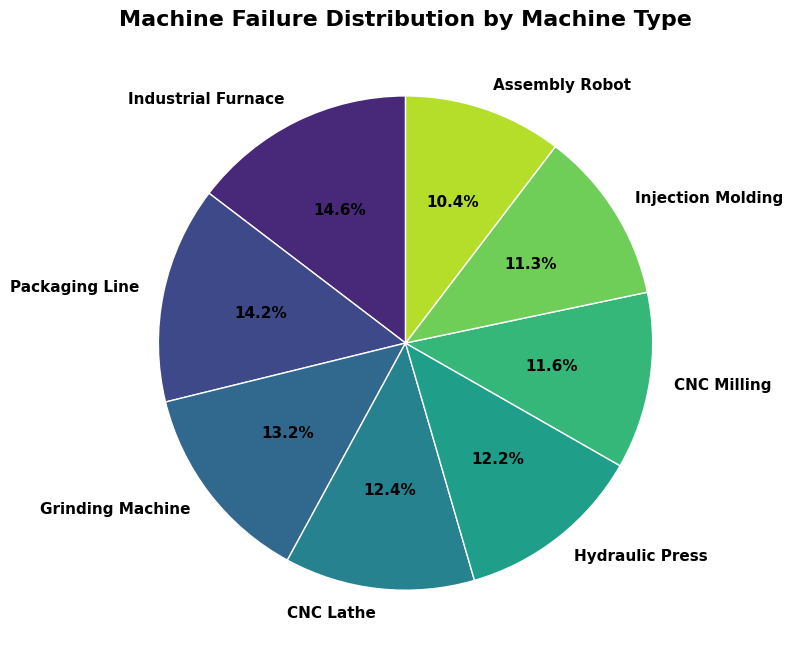

In [23]:
plt.figure(figsize=(8, 8))

colors = sns.color_palette("viridis", len(machine_type_failure))
plt.pie(
    machine_type_failure["Total_Machine_Failure"],
    labels=machine_type_failure["Machine_Type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 11, "fontweight": "bold"}
)
plt.title(
    "Machine Failure Distribution by Machine Type",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Business Insight

### Industrial Furnaces account for the largest share of machine failures (14.6%), closely followed by Packaging Lines (14.2%) and Grinding Machines (13.2%). No single machine type dominates the failures, indicating that maintenance efforts should be distributed across multiple equipment categories rather than focusing on one type alone.

## Recommendation

### Prioritize preventive maintenance for Industrial Furnaces and Packaging Lines due to their relatively higher contribution to total failures. Since the failure distribution is fairly balanced across machine types, implement equipment-specific maintenance strategies across all major machine categories instead of concentrating resources on a single type.

In [24]:
query = """SELECT
    shift,
    SUM(defective_units) AS Total_Defective_Units,
    SUM(units_produced) AS Total_Units_Produced,
    ROUND(
        (SUM(defective_units) * 100.0) /
        SUM(units_produced),
        2
    ) AS Defect_Percentage
FROM production_batches
GROUP BY shift
ORDER BY Defect_Percentage DESC;"""

shift_defect = pd.read_sql(query,engine)
shift_defect

,shift,Total_Defective_Units,Total_Units_Produced,Defect_Percentage
0,Night,1946898.0,21969106.0,8.86
1,Evening,2202944.0,30971752.0,7.11
2,Morning,2426201.0,34156102.0,7.10


C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\448937292.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


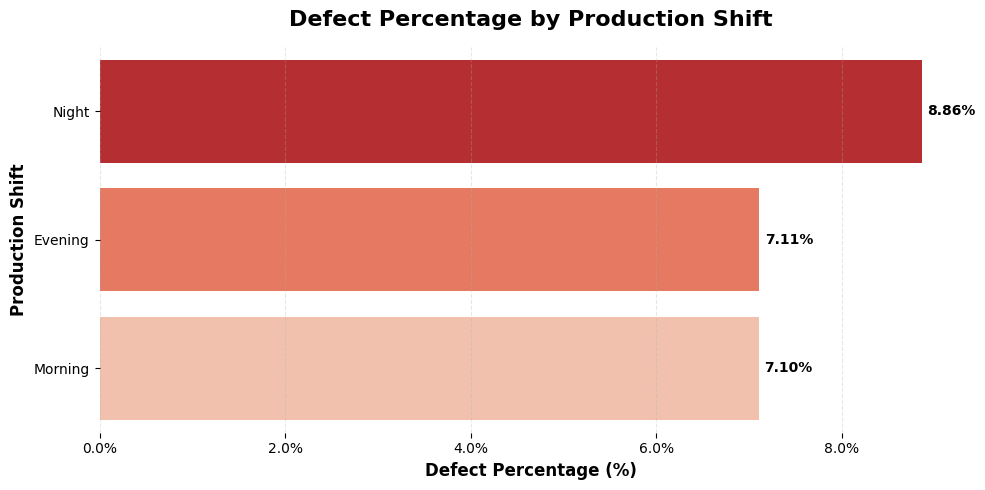

In [25]:
plt.figure(figsize=(10, 5))

palette = sns.color_palette("Reds_r", len(shift_defect))
ax = sns.barplot(
    data=shift_defect,
    y="shift",
    x="Defect_Percentage",
    palette=palette
)

ax.set_title(
    "Defect Percentage by Production Shift",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Defect Percentage (%)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Production Shift",
    fontsize=12,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Business Insight

### The Night Shift recorded the highest defect rate (8.86%), indicating that it produces the largest proportion of defective units relative to its total production. In comparison, the Morning (7.10%) and Evening (7.11%) shifts maintained lower defect rates. This suggests that production quality is comparatively weaker during the Night Shift and requires further operational investigation.

## Business Recommendation

### Prioritize a quality review of the Night Shift by analyzing operator performance, machine health, maintenance activities, production workload, and raw material quality. Identifying the root causes of the higher defect rate can help reduce production losses, improve product quality, and increase overall manufacturing efficiency.

In [26]:
query = """SELECT
    o.operator_name,
    COUNT(pb.batch_id) AS Total_Batches,
    SUM(pb.good_units) AS Total_Good_Units,
    SUM(pb.units_produced) AS Total_Units,
    ROUND(
        SUM(pb.good_units) * 100.0 /
        SUM(pb.units_produced),
        2
    ) AS Quality_Percentage
FROM production_batches pb
JOIN operators o
    ON pb.operator_id = o.operator_id
WHERE pb.operator_id IS NOT NULL
GROUP BY
    o.operator_name
HAVING COUNT(pb.batch_id) >= 10
ORDER BY Quality_Percentage DESC
LIMIT 10;"""

operator_quality = pd.read_sql(query,engine)
operator_quality    

,operator_name,Total_Batches,Total_Good_Units,Total_Units,Quality_Percentage
0,Vivaan Singh,306,415853.0,444303.0,93.60
1,Arjun Reddy,108,158721.0,169584.0,93.59
2,Ananya Verma,375,509913.0,545086.0,93.55
3,Neha Verma,284,382464.0,408813.0,93.55
4,Ananya Nair,170,235688.0,251984.0,93.53
5,Vikram Patel,315,435511.0,466009.0,93.46
6,Aarav Sharma,171,224508.0,240260.0,93.44
7,Meera Mehta,177,228530.0,244615.0,93.42
8,Neha Kumar,320,435608.0,466378.0,93.40
9,Aditya Mehta,346,491288.0,526168.0,93.37


## Business Insight

### Vivaan Singh achieved the highest quality performance among the top operators, maintaining a 93.60% quality rate across 306 production batches. Similarly, Ananya Verma (375 batches), Neha Verma (284 batches), and Vikram Patel (315 batches) consistently maintained quality percentages above 93% while handling a high production workload. This indicates that these operators are able to sustain high product quality over a large number of production runs, making them strong candidates for benchmarking best manufacturing practices.

## Business Recommendation

### Analyze the work practices, machine allocation, training, and standard operating procedures (SOPs) followed by these high-performing operators. Their methods can be incorporated into operator training programs to improve quality consistency across the workforce. At the same time, monitor operators with lower quality percentages to identify opportunities for targeted coaching and process improvement.


C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\1722228564.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


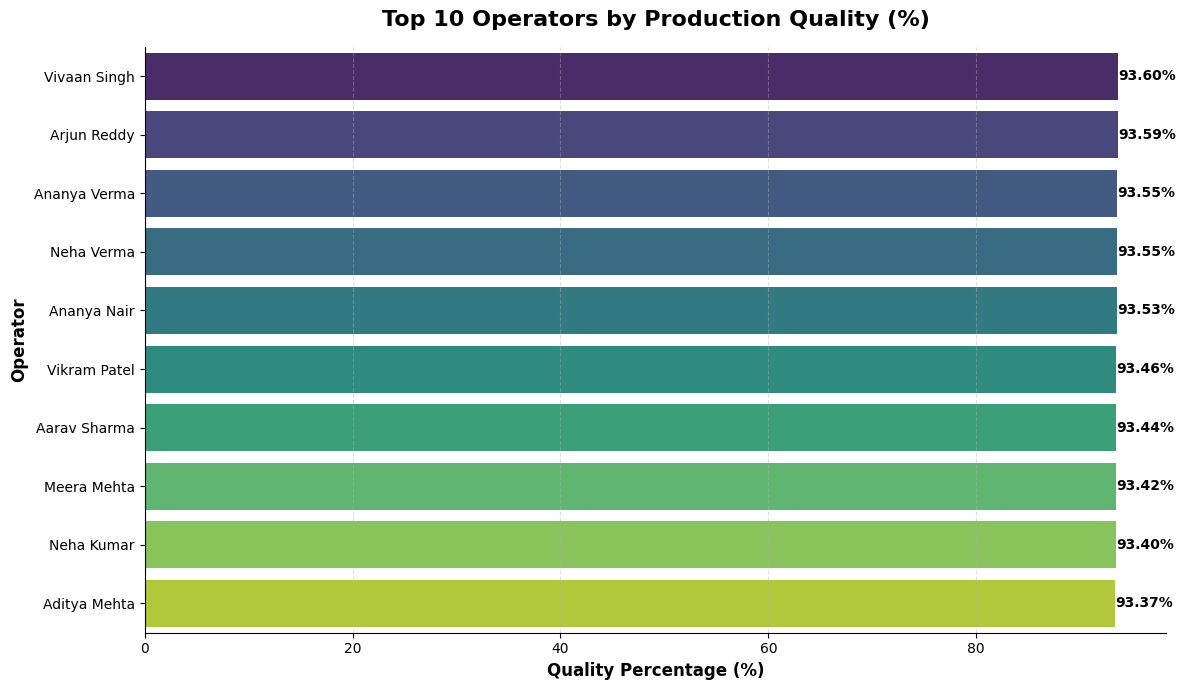

In [27]:

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=operator_quality,
    y="operator_name",
    x="Quality_Percentage",
    palette="viridis"
)

for i, value in enumerate(operator_quality["Quality_Percentage"]):
    plt.text(
        value + 0.02,     # Move text slightly outside the bar
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Operators by Production Quality (%)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Quality Percentage (%)", fontsize=12, fontweight="bold")
plt.ylabel("Operator", fontsize=12, fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

In [28]:
query = """SELECT
    o.operator_name,
    COUNT(pb.batch_id) AS Total_Batches,
    SUM(pb.good_units) AS Total_Good_Units,
    SUM(pb.units_produced) AS Total_Units,
    ROUND(
        SUM(pb.good_units) * 100.0 /
        SUM(pb.units_produced),
        2
    ) AS Quality_Percentage
FROM production_batches pb
JOIN operators o
    ON pb.operator_id = o.operator_id
WHERE pb.operator_id IS NOT NULL
GROUP BY
    o.operator_name
HAVING COUNT(pb.batch_id) >= 10
ORDER BY Quality_Percentage ASC
LIMIT 10;""" 

bottom_opreator =pd.read_sql(query,engine)
bottom_opreator

,operator_name,Total_Batches,Total_Good_Units,Total_Units,Quality_Percentage
0,Aarav Nair,128,161731.0,178578.0,90.57
1,Aarav Yadav,187,244729.0,269421.0,90.84
2,Nitin Gupta,173,225791.0,248449.0,90.88
3,Kavya Verma,251,326128.0,358645.0,90.93
4,Riya Patel,179,221989.0,244135.0,90.93
5,Aman Mehta,63,81183.0,89183.0,91.03
6,Rahul Mehta,442,562701.0,617176.0,91.17
7,Vikram Verma,105,153119.0,167911.0,91.19
8,Pooja Kumar,170,223642.0,244967.0,91.29
9,Nitin Reddy,73,81224.0,88958.0,91.31


## Business Insight

### The analysis indicates that operator performance is generally consistent across the manufacturing workforce. Even the bottom-performing operators maintain quality percentages above 90%, while the top performers achieve around 93.6%. This relatively small performance gap suggests that the manufacturing process is well standardized and that operator performance is not the primary driver of quality issues.


In [29]:
sensor_readings = pd.read_sql(
    """
    SELECT *
    FROM sensor_readings;
    """,
    engine
)

sensor_readings.head()

,sensor_reading_id,machine_id,line_id,factory_id,reading_timestamp,temperature_c,vibration_mm_s,pressure_bar,oil_level_percent,voltage_v,current_amp,rpm,sound_level_db,machine_health_score,alert_status,failure_within_7_days,linked_failure_event_id
0,SNS0000001,MCH0212,LIN030,FAC010,2025-01-28 19:38:45,33.25,3.692,5.33,76.90,412.77,33.29,878.2,71.68,82,Normal,0,NaN
1,SNS0000002,MCH0134,LIN006,FAC002,2026-05-05 18:25:04,60.37,3.179,5.04,85.60,413.53,38.28,1437.8,75.88,93,Normal,0,NaN
2,SNS0000003,MCH0227,LIN023,FAC008,2024-12-23 19:29:20,70.58,0.888,5.12,71.21,429.69,27.93,1762.9,69.30,97,Normal,0,NaN
3,SNS0000004,MCH0059,LIN012,FAC004,2023-05-17 02:02:47,42.87,2.900,3.83,63.01,430.38,28.13,746.3,69.73,88,Normal,0,NaN
4,SNS0000005,MCH0474,LIN003,FAC001,2025-08-10 14:59:02,60.29,4.685,6.27,73.69,409.80,44.78,1212.4,63.75,83,Normal,0,NaN


C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\2389804907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


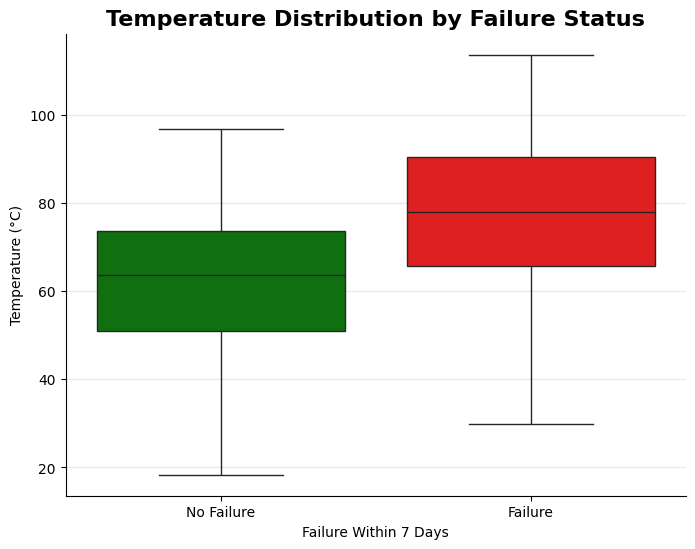

In [30]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=sensor_readings,
    x="failure_within_7_days",
    y="temperature_c",
    palette=["green", "red"],
    showfliers=False
)

plt.xticks([0, 1], ["No Failure", "Failure"])

plt.title("Temperature Distribution by Failure Status",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Failure Within 7 Days")
plt.ylabel("Temperature (°C)")

plt.grid(axis="y", alpha=0.3)
sns.despine()

plt.show()

In [31]:
sensor_readings.groupby("failure_within_7_days")["temperature_c"].mean()

failure_within_7_days
0    100.752976
1    117.507475
Name: temperature_c, dtype: float64

## Business Insight

### Machines that experienced failures within seven days generally operated at higher temperatures than machines that continued normal operation. The higher median temperature and upward shift in the failure group's distribution indicate that elevated operating temperatures are associated with an increased likelihood of machine failure. Temperature can therefore serve as an important early warning indicator for equipment health.

## Business Recommendation

### Implement continuous temperature monitoring and configure automated alerts when machines consistently exceed their normal operating temperature range. Machines showing sustained high temperatures should be prioritized for inspection and preventive maintenance to reduce unexpected breakdowns, improve equipment reliability, and minimize production downtime.

In [32]:
products = pd.read_sql(
    """
    SELECT *
    FROM products;
    """,
    engine
)

products.head()

,product_id,supplier_id,product_name,product_category,material,process_complexity,target_cycle_time_minutes,standard_unit_cost_inr,dimensional_tolerance_mm,quality_grade
0,PRD0001,SUP0143,Packaging Unit 001,Packaging Unit,ABS Plastic,Medium,4.24,5072.36,0.424,A
1,PRD0002,SUP0183,Electrical Component 002,Electrical Component,Steel,High,4.36,5589.11,0.246,C
2,PRD0003,SUP0011,Automotive Part 003,Automotive Part,Aluminium,Low,7.03,849.10,0.278,A
3,PRD0004,SUP0073,Automotive Part 004,Automotive Part,Composite,Low,5.58,2074.65,0.130,A
4,PRD0005,SUP0166,Plastic Component 005,Plastic Component,ABS Plastic,Medium,6.03,4581.27,0.398,A


In [33]:
suppliers = pd.read_sql(
    """
    SELECT *
    FROM suppliers;
    """,
    engine
)

suppliers.head()

,supplier_id,supplier_name,region,supplier_category,quality_rating,average_lead_time_days,delivery_reliability,supplier_status
0,SUP0001,Industrial Supplier 001,West,Electronic Parts,0.938,33,0.903,Approved
1,SUP0002,Industrial Supplier 002,East,Mechanical Parts,0.828,8,0.883,Approved
2,SUP0003,Industrial Supplier 003,South,Electronic Parts,0.955,9,0.816,Approved
3,SUP0004,Industrial Supplier 004,West,Electronic Parts,0.946,6,0.890,Approved
4,SUP0005,Industrial Supplier 005,North,Mechanical Parts,0.851,35,0.834,Approved


In [34]:
production_batches = pd.read_sql(
    """
    SELECT *
    FROM production_batches;
    """,
    engine
)

production_batches.columns

Index(['batch_id', 'machine_id', 'line_id', 'factory_id', 'product_id',
       'supplier_id', 'operator_id', 'production_date', 'start_time', 'shift',
       'planned_quantity', 'units_produced', 'good_units', 'defective_units',
       'scrap_units', 'rework_units', 'runtime_hours', 'downtime_hours',
       'availability_ratio', 'actual_cycle_time_minutes',
       'energy_consumption_kwh', 'scrap_cost_inr', 'batch_status',
       'failure_near_batch'],
      dtype='str')

In [35]:
query ="""SELECT
    p.product_name,
    ROUND(SUM(pb.scrap_cost_inr)) AS Total_Scrap_Cost
FROM production_batches pb
JOIN products p
    ON pb.product_id = p.product_id
GROUP BY p.product_name
ORDER BY Total_Scrap_Cost DESC
LIMIT 10;"""

scrap_cost = pd.read_sql(query,engine)
scrap_cost

,product_name,Total_Scrap_Cost
0,Plastic Component 068,133265276.0
1,Packaging Unit 115,128900470.0
2,Mechanical Part 140,128017520.0
3,Electrical Component 002,125223972.0
4,Automotive Part 086,119616571.0
5,Plastic Component 126,118976769.0
6,Mechanical Part 041,117831208.0
7,Plastic Component 089,116532646.0
8,Plastic Component 122,113725693.0
9,Mechanical Part 062,110377435.0


C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\3041168907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


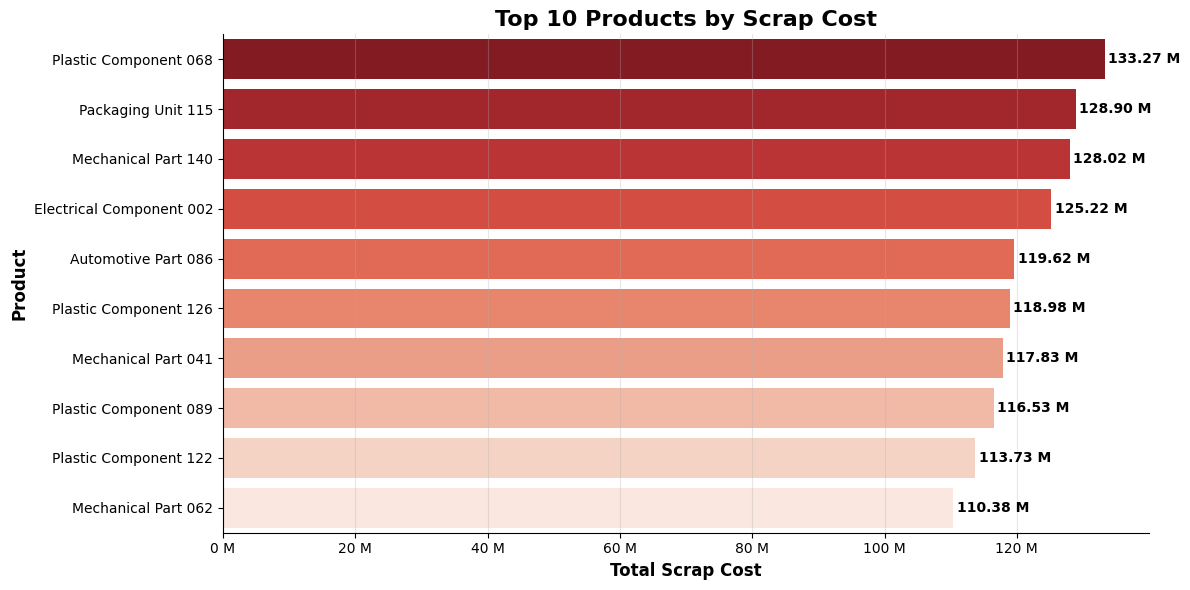

In [36]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=scrap_cost,
    y="product_name",
    x="Total_Scrap_Cost",
    palette="Reds_r"
)

for i, value in enumerate(scrap_cost["Total_Scrap_Cost"]):
    plt.text(
        value + 500000,          
        i,
        f"{value/1_000_000:.2f} M",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Products by Scrap Cost",
    fontsize=16,
    fontweight="bold"
)


ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f} M")
)


plt.xlabel("Total Scrap Cost", fontsize=12, fontweight="bold")
plt.ylabel("Product", fontsize=12, fontweight="bold")

plt.grid(axis="x", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Business Insight

### Plastic Component 068 generated the highest scrap cost (133.27 M), followed by Packaging Unit 115 (128.90 M) and Mechanical Part 140 (128.02 M). These products account for the highest manufacturing waste and represent significant financial losses due to defective production or material scrap.

## Business Recommendation

### Prioritize a root cause analysis for the products with the highest scrap costs by evaluating production processes, machine performance, raw material quality, and quality inspection outcomes. Reducing scrap for these products can significantly improve manufacturing efficiency, lower production costs, and increase overall profitability.

In [37]:
query = """SELECT
    m.machine_id,
    m.model,
    m.machine_type,
    COUNT(mw.work_order_id) AS Total_Maintenance
FROM maintenance_work_orders mw
JOIN machines m
ON mw.machine_id = m.machine_id
GROUP BY
    m.machine_id,
    m.model,
    m.machine_type
ORDER BY Total_Maintenance DESC
LIMIT 10;"""

pd.read_sql(query,engine)

,machine_id,model,machine_type,Total_Maintenance
0,MCH0031,THE-547,Industrial Furnace,37
1,MCH0238,SCH-324,Hydraulic Press,36
2,MCH0179,DMG-302,CNC Lathe,36
3,MCH0555,THE-623,Industrial Furnace,33
4,MCH0105,SCH-293,Hydraulic Press,33
5,MCH0369,KRO-213,Packaging Line,33
6,MCH0054,MAK-248,CNC Milling,33
7,MCH0180,THE-444,Industrial Furnace,32
8,MCH0396,THE-344,Industrial Furnace,32
9,MCH0482,KRO-908,Packaging Line,32


In [38]:
query = """SELECT
    m.machine_type,
    COUNT(mw.work_order_id) AS Total_Maintenance
FROM maintenance_work_orders mw
JOIN machines m
ON mw.machine_id = m.machine_id
GROUP BY m.machine_type
ORDER BY Total_Maintenance DESC;"""

machine_type_maintenance = pd.read_sql(query,engine)
machine_type_maintenance

,machine_type,Total_Maintenance
0,Industrial Furnace,1779
1,Packaging Line,1750
2,CNC Lathe,1531
3,Grinding Machine,1531
4,Hydraulic Press,1493
5,CNC Milling,1392
6,Injection Molding,1329
7,Assembly Robot,1195


C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\1721730380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


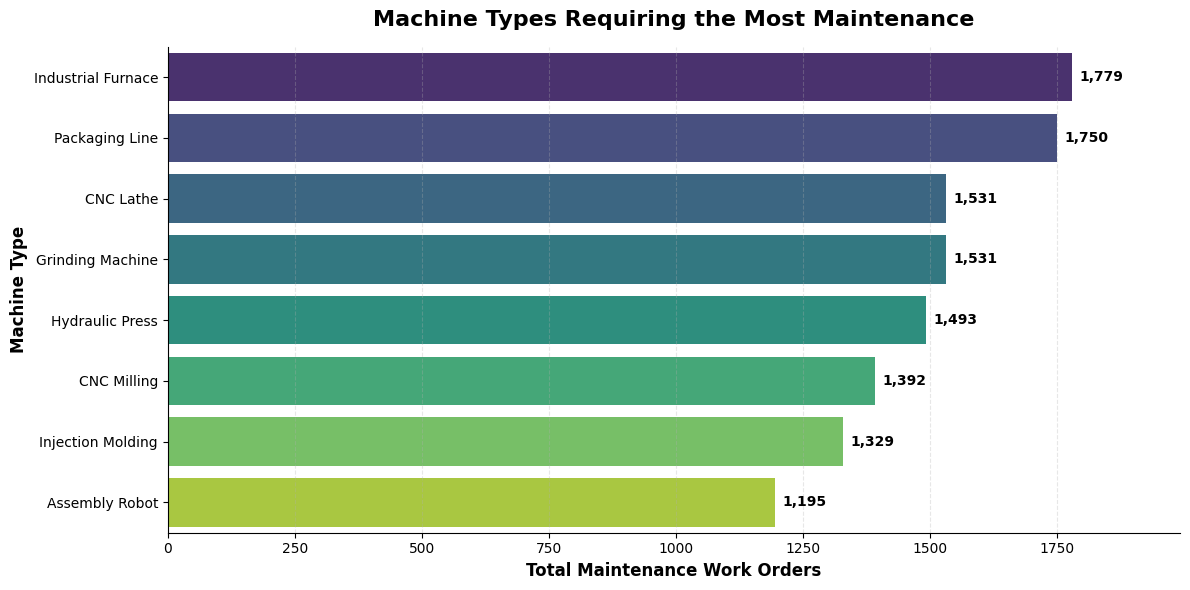

In [39]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=machine_type_maintenance,
    y="machine_type",
    x="Total_Maintenance",
    palette="viridis"
)

# Add value labels
for i, value in enumerate(machine_type_maintenance["Total_Maintenance"]):
    plt.text(
        value + 15,
        i,
        f"{value:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Machine Types Requiring the Most Maintenance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Total Maintenance Work Orders",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Machine Type",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.xlim(0, machine_type_maintenance["Total_Maintenance"].max() * 1.12)

plt.tight_layout()
plt.show()

## Business Insight

### Industrial Furnaces required the highest number of maintenance activities (1,779), followed closely by Packaging Lines (1,750) and CNC Lathes (1,531). This indicates that these machine types demand more maintenance effort than others, either because of higher operational workloads, greater mechanical complexity, or more frequent servicing requirements. These assets should be considered high-priority equipment for maintenance planning and reliability improvement initiatives.

In [40]:
downtime_events = pd.read_sql(
    """
    SELECT *
    FROM downtime_events;
    """,
    engine
)

downtime_events.head(10)

,downtime_event_id,machine_id,line_id,factory_id,linked_failure_event_id,linked_work_order_id,event_timestamp,downtime_cause,duration_hours,estimated_lost_units,estimated_loss_inr,resolution_status,impact_level
0,DTE000001,MCH0296,LIN026,FAC009,FLR000001,MWO000001,2026-02-12 11:52:47,Machine Breakdown,4.96,549,398037.83,Resolved,Medium
1,DTE000002,MCH0573,LIN004,FAC002,FLR000002,MWO000002,2025-05-24 10:22:32,Machine Breakdown,4.01,634,671146.80,Resolved,High
2,DTE000003,MCH0388,LIN011,FAC004,FLR000003,MWO000003,2023-08-11 10:12:05,Machine Breakdown,10.37,2025,1574258.15,Resolved,Medium
3,DTE000004,MCH0202,LIN009,FAC003,FLR000004,MWO000004,2024-01-01 21:26:00,Machine Breakdown,17.13,3692,3308032.43,Resolved,Medium
4,DTE000005,MCH0321,LIN029,FAC010,FLR000005,MWO000005,2025-04-01 13:33:41,Machine Breakdown,5.65,651,409580.56,Resolved,Low
5,DTE000006,MCH0600,LIN014,FAC005,FLR000006,MWO000006,2025-02-04 01:05:08,Machine Breakdown,6.53,1556,1829715.18,Resolved,Low
6,DTE000007,MCH0442,LIN001,FAC001,FLR000007,MWO000007,2024-08-23 12:00:31,Machine Breakdown,11.24,1800,1740735.24,Open,High
7,DTE000008,MCH0212,LIN030,FAC010,FLR000008,MWO000008,2025-07-16 05:02:34,Machine Breakdown,6.69,1091,1253542.61,Resolved,Low
8,DTE000009,MCH0287,LIN017,FAC006,FLR000009,MWO000009,2024-10-17 03:39:42,Machine Breakdown,2.21,423,209454.81,Resolved,High
9,DTE000010,MCH0466,LIN005,FAC002,FLR000010,MWO000010,2024-04-02 08:38:36,Machine Breakdown,2.81,165,67192.71,Resolved,Critical


In [41]:
query = """SELECT
    ROUND(SUM(estimated_loss_inr) / 1000000, 2) AS Total_Downtime_Loss_Million
FROM downtime_events;"""

pd.read_sql(query,engine)

,Total_Downtime_Loss_Million
0,3982.59


In [42]:
query = """SELECT
    f.factory_name,
    ROUND(SUM(d.estimated_loss_inr) / 1000000, 2) AS Downtime_Loss_Million
FROM downtime_events d
JOIN factories f
ON d.factory_id = f.factory_id
GROUP BY f.factory_name
ORDER BY Downtime_Loss_Million DESC;"""

factory_downtime = pd.read_sql(query,engine)
factory_downtime

,factory_name,Downtime_Loss_Million
0,Chennai Manufacturing Plant,452.61
1,Gurugram Manufacturing Plant,442.30
2,Kolkata Manufacturing Plant,425.89
3,Bengaluru Manufacturing Plant,418.97
4,Ahmedabad Manufacturing Plant,415.56
5,Pune Manufacturing Plant,414.53
6,Indore Manufacturing Plant,385.27
7,Hyderabad Manufacturing Plant,383.76
8,Noida Manufacturing Plant,322.62
9,Jamshedpur Manufacturing Plant,321.09


C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\3060396580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


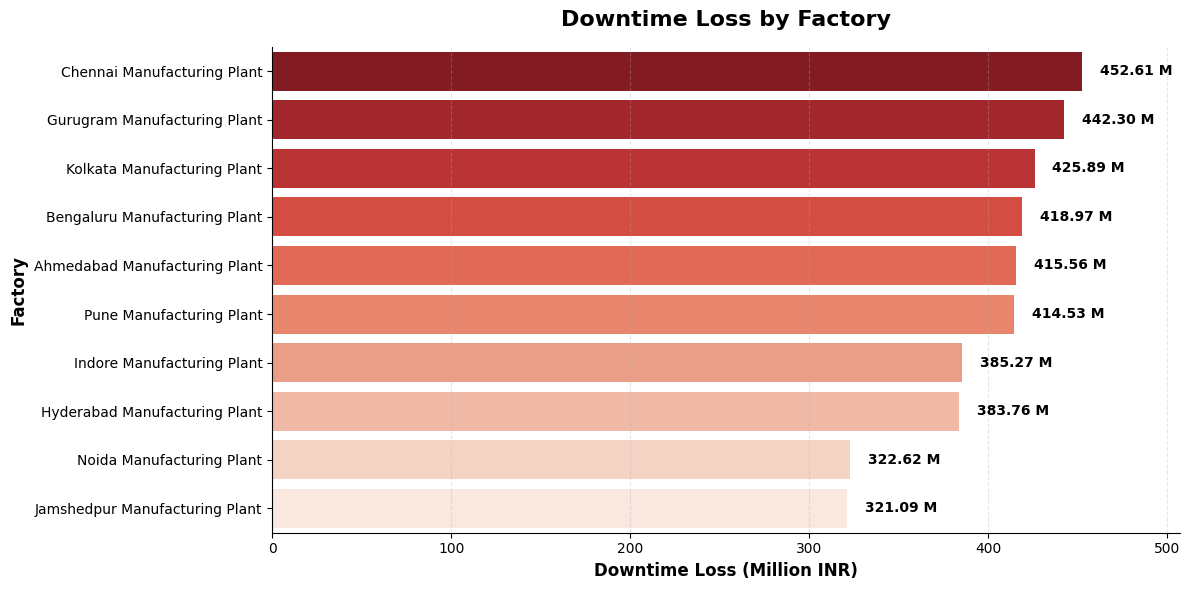

In [43]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=factory_downtime,
    y="factory_name",
    x="Downtime_Loss_Million",
    palette="Reds_r"
)

for i, value in enumerate(factory_downtime["Downtime_Loss_Million"]):
    plt.text(
        value + 10,
        i,
        f"{value:.2f} M",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Downtime Loss by Factory",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Downtime Loss (Million INR)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Factory",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.xlim(0, factory_downtime["Downtime_Loss_Million"].max() * 1.12)

plt.tight_layout()
plt.show()

## Business Insight

### The factories with the highest estimated downtime losses contribute the largest share of financial impact from production interruptions. These facilities should be prioritized for operational improvements, equipment reliability initiatives, and maintenance optimization to minimize future losses.

## Business Recommendation

### Conduct a root cause analysis of downtime events at the highest-loss factories. Strengthen preventive maintenance, improve spare parts availability, and implement predictive monitoring for critical equipment to reduce production interruptions and associated financial losses.

In [44]:
maintenance_work_orders= pd.read_sql(
    """
    SELECT *
    FROM maintenance_work_orders;
    """,
    engine
)

maintenance_work_orders.head(10)

,work_order_id,machine_id,line_id,factory_id,linked_failure_event_id,scheduled_timestamp,completion_timestamp,maintenance_type,maintenance_reason,action_taken,maintenance_downtime_hours,parts_cost_inr,labor_cost_inr,total_maintenance_cost_inr,technician_id,work_order_status
0,MWO000001,MCH0340,LIN012,FAC004,FLR001989,2025-10-03 06:50:27,2025-10-03 09:10:51,Corrective,Overheating,Inspection,2.34,20299.29,3370.41,23669.70,TECH067,Completed
1,MWO000002,MCH0459,LIN006,FAC002,FLR000903,2024-07-13 19:21:54,2024-07-13 21:11:06,Corrective,Bearing Failure,Calibration,1.82,16948.13,2161.39,19109.52,TECH060,Completed
2,MWO000003,MCH0470,LIN002,FAC001,FLR001426,2024-06-22 01:36:00,2024-06-22 11:34:12,Emergency,Sensor Failure,Replace Component,9.97,69284.59,15474.64,84759.23,TECH138,Completed
3,MWO000004,MCH0536,LIN030,FAC010,FLR002583,2026-03-01 22:00:30,2026-03-02 01:26:54,Corrective,Electrical Fault,Lubrication,3.44,12240.71,4715.12,16955.83,TECH089,Completed
4,MWO000005,MCH0160,LIN018,FAC006,FLR002948,2024-08-22 01:19:01,2024-08-22 09:22:01,Corrective,Excessive Vibration,Alignment,8.05,48792.04,11157.91,59949.95,TECH098,Completed
5,MWO000006,MCH0172,LIN008,FAC003,FLR000315,2023-09-17 00:23:38,2023-09-17 03:14:02,Corrective,Excessive Vibration,Electrical Repair,2.84,5003.30,6451.77,11455.07,TECH097,Completed
6,MWO000007,MCH0062,LIN011,FAC004,FLR000979,2024-12-18 13:59:22,2024-12-18 22:16:46,Emergency,Tool Wear,Electrical Repair,8.29,52120.08,15981.29,68101.37,TECH083,Completed
7,MWO000008,MCH0495,LIN009,FAC003,FLR001554,2024-02-25 15:46:33,2024-02-25 21:56:09,Emergency,Tool Wear,Replace Component,6.16,36401.95,9624.77,46026.72,TECH094,Completed
8,MWO000009,MCH0363,LIN017,FAC006,FLR002020,2023-01-13 04:35:51,2023-01-13 05:52:03,Corrective,Sensor Failure,Replace Component,1.27,7831.12,1818.79,9649.91,TECH088,In Progress
9,MWO000010,MCH0306,LIN010,FAC004,FLR002155,2023-07-05 03:48:17,2023-07-05 08:03:17,Corrective,Tool Wear,Electrical Repair,4.25,30178.14,5544.31,35722.45,TECH055,Completed


In [45]:
query = """SELECT 
m.machine_type, 
ROUND(AVG(mw.total_maintenance_cost_inr)) AS Average_Maintenance_Cost
FROM machines m 
JOIN maintenance_work_orders mw 
ON m.machine_id = mw.machine_id 
GROUP BY m.machine_type
ORDER BY Average_Maintenance_Cost DESC;
"""

maintenance_cost=pd.read_sql(query,engine)
maintenance_cost

,machine_type,Average_Maintenance_Cost
0,Industrial Furnace,28015.0
1,Hydraulic Press,27960.0
2,Grinding Machine,27498.0
3,Assembly Robot,27328.0
4,CNC Milling,27298.0
5,CNC Lathe,26994.0
6,Packaging Line,26987.0
7,Injection Molding,26818.0


## Business Insight

## Industrial Furnaces incur the highest average maintenance cost (₹28,015 per work order), followed by Hydraulic Presses (₹27,960) and Grinding Machines (₹27,498). The relatively small variation in average maintenance costs across machine types suggests that maintenance expenses are fairly consistent throughout the manufacturing facility, although Industrial Furnaces remain the most expensive equipment to maintain on average.

C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\1014735537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


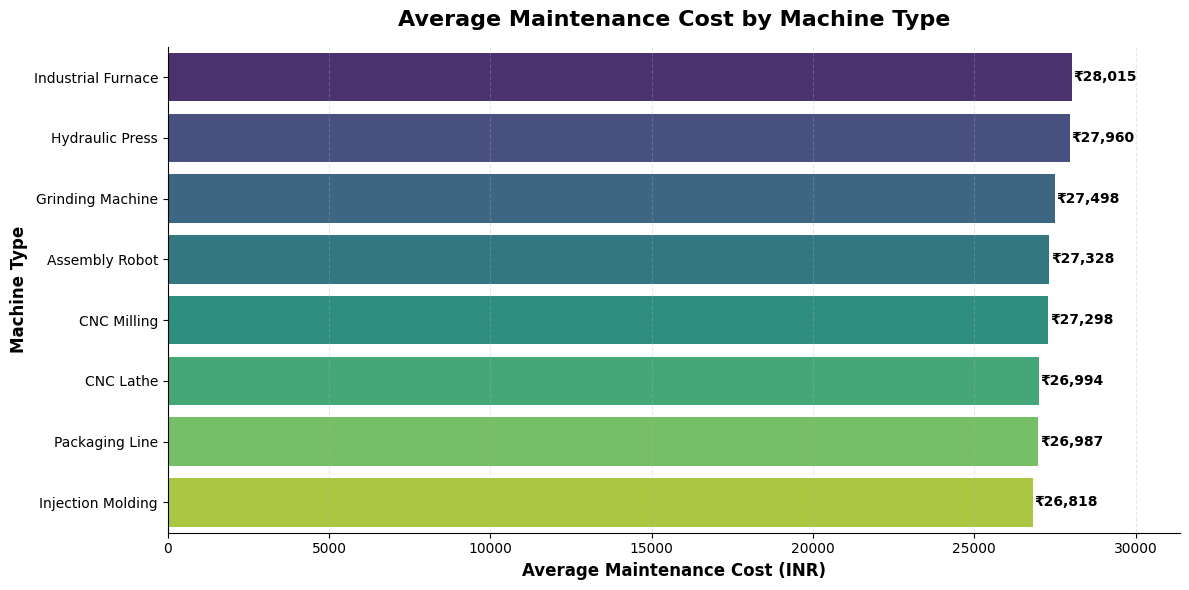

In [46]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=maintenance_cost,
    y="machine_type",
    x="Average_Maintenance_Cost",
    palette="viridis"
)

# Value labels
for i, value in enumerate(maintenance_cost["Average_Maintenance_Cost"]):
    plt.text(
        value + 50,
        i,
        f"₹{value:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Average Maintenance Cost by Machine Type",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Average Maintenance Cost (INR)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Machine Type",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.xlim(
    0,
    maintenance_cost["Average_Maintenance_Cost"].max() * 1.12
)

plt.tight_layout()
plt.show()

In [47]:
query = """SELECT
    m.machine_id,
    m.model,
    m.machine_type,
    COUNT(DISTINCT fe.failure_event_id) AS Total_Failures,
    COUNT(DISTINCT mw.work_order_id) AS Total_Maintenance
FROM machines m
LEFT JOIN failure_events fe
    ON m.machine_id = fe.machine_id
LEFT JOIN maintenance_work_orders mw
    ON m.machine_id = mw.machine_id
GROUP BY
    m.machine_id,
    m.model,
    m.machine_type
HAVING
    COUNT(DISTINCT fe.failure_event_id) > 0
ORDER BY
    Total_Failures DESC,
    Total_Maintenance DESC
LIMIT 10;""" 

proactive_maintenance = pd.read_sql(query,engine)
proactive_maintenance

,machine_id,model,machine_type,Total_Failures,Total_Maintenance
0,MCH0120,BOS-903,Grinding Machine,12,24
1,MCH0549,DMG-287,CNC Lathe,12,24
2,MCH0396,THE-344,Industrial Furnace,11,32
3,MCH0133,DMG-282,CNC Lathe,11,31
4,MCH0101,KRO-648,Packaging Line,11,22
5,MCH0180,THE-444,Industrial Furnace,10,32
6,MCH0228,DMG-623,CNC Lathe,10,31
7,MCH0166,DMG-667,CNC Lathe,10,29
8,MCH0415,SCH-129,Hydraulic Press,10,28
9,MCH0056,THE-321,Industrial Furnace,10,27


In [48]:
proactive_maintenance = proactive_maintenance.sort_values(
    by=["Total_Maintenance", "Total_Failures"],
    ascending=False
)

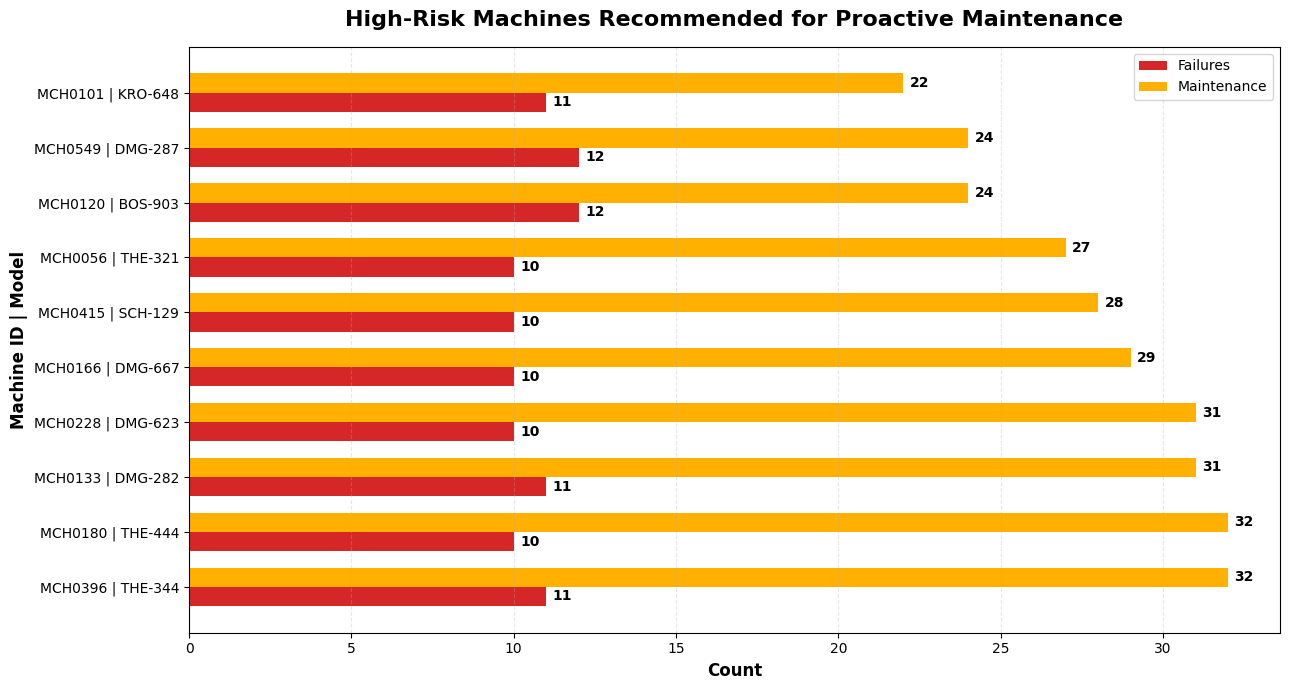

In [49]:
plt.figure(figsize=(13, 7))

y = np.arange(len(proactive_maintenance))
bar_width = 0.35

plt.barh(
    y - bar_width/2,
    proactive_maintenance["Total_Failures"],
    height=bar_width,
    label="Failures",
    color="#d62728"
)

plt.barh(
    y + bar_width/2,
    proactive_maintenance["Total_Maintenance"],
    height=bar_width,
    label="Maintenance",
    color="#ffb000"
)

# Value labels
for i, value in enumerate(proactive_maintenance["Total_Failures"]):
    plt.text(
        value + 0.2,
        i - bar_width/2,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

for i, value in enumerate(proactive_maintenance["Total_Maintenance"]):
    plt.text(
        value + 0.2,
        i + bar_width/2,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Machine labels
labels = (
    proactive_maintenance["machine_id"] +
    " | " +
    proactive_maintenance["model"]
)

plt.yticks(y, labels)

plt.title(
    "High-Risk Machines Recommended for Proactive Maintenance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Count", fontsize=12, fontweight="bold")
plt.ylabel("Machine ID | Model", fontsize=12, fontweight="bold")

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Business Insight

### Several machines exhibit both a high number of failure events and frequent maintenance work orders. MCH0396 (Industrial Furnace), MCH0180 (Industrial Furnace), MCH0133 (CNC Lathe), and MCH0228 (CNC Lathe) require more than 30 maintenance work orders while also recording 10–11 failure events. These machines represent high-risk assets that should be prioritized for proactive maintenance and reliability improvement initiatives.

## Business Recommendation

### Prioritize these machines for predictive maintenance by reviewing maintenance history, replacing frequently failing components, and implementing continuous condition monitoring. Addressing recurring issues before failures occur can reduce unplanned downtime, improve equipment reliability, and lower long-term maintenance costs.

In [50]:
sensor_readings

,sensor_reading_id,machine_id,line_id,factory_id,reading_timestamp,temperature_c,vibration_mm_s,pressure_bar,oil_level_percent,voltage_v,current_amp,rpm,sound_level_db,machine_health_score,alert_status,failure_within_7_days,linked_failure_event_id
0,SNS0000001,MCH0212,LIN030,FAC010,2025-01-28 19:38:45,33.25,3.692,5.33,76.90,412.77,33.29,878.2,71.68,82,Normal,0,NaN
1,SNS0000002,MCH0134,LIN006,FAC002,2026-05-05 18:25:04,60.37,3.179,5.04,85.60,413.53,38.28,1437.8,75.88,93,Normal,0,NaN
2,SNS0000003,MCH0227,LIN023,FAC008,2024-12-23 19:29:20,70.58,0.888,5.12,71.21,429.69,27.93,1762.9,69.30,97,Normal,0,NaN
3,SNS0000004,MCH0059,LIN012,FAC004,2023-05-17 02:02:47,42.87,2.900,3.83,63.01,430.38,28.13,746.3,69.73,88,Normal,0,NaN
4,SNS0000005,MCH0474,LIN003,FAC001,2025-08-10 14:59:02,60.29,4.685,6.27,73.69,409.80,44.78,1212.4,63.75,83,Normal,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284995,SNS0284996,MCH0264,LIN030,FAC010,2026-04-30 18:31:19,82.71,1.941,6.31,55.70,421.06,47.61,2046.6,79.42,83,Normal,0,NaN
284996,SNS0284997,MCH0030,LIN022,FAC008,2025-02-21 22:41:29,66.70,2.782,4.93,76.55,431.62,45.62,1831.7,74.70,90,Normal,0,NaN
284997,SNS0284998,MCH0238,LIN007,FAC003,2024-04-06 22:28:52,70.58,4.517,6.28,76.30,399.74,34.90,1182.3,75.04,86,Normal,0,NaN
284998,SNS0284999,MCH0376,LIN005,FAC002,2024-06-08 14:09:37,41.48,2.978,7.45,81.52,425.55,39.50,588.3,72.25,87,Normal,0,NaN


In [51]:
query = """SELECT
    temperature_c,
    vibration_mm_s,
    pressure_bar,
    oil_level_percent,
    voltage_v,
    current_amp,
    rpm,
    sound_level_db,
    machine_health_score,
    failure_within_7_days
FROM sensor_readings;"""

pd.read_sql(query,engine)

,temperature_c,vibration_mm_s,pressure_bar,oil_level_percent,voltage_v,current_amp,rpm,sound_level_db,machine_health_score,failure_within_7_days
0,33.25,3.692,5.33,76.90,412.77,33.29,878.2,71.68,82,0
1,60.37,3.179,5.04,85.60,413.53,38.28,1437.8,75.88,93,0
2,70.58,0.888,5.12,71.21,429.69,27.93,1762.9,69.30,97,0
3,42.87,2.900,3.83,63.01,430.38,28.13,746.3,69.73,88,0
4,60.29,4.685,6.27,73.69,409.80,44.78,1212.4,63.75,83,0
...,...,...,...,...,...,...,...,...,...,...
284995,82.71,1.941,6.31,55.70,421.06,47.61,2046.6,79.42,83,0
284996,66.70,2.782,4.93,76.55,431.62,45.62,1831.7,74.70,90,0
284997,70.58,4.517,6.28,76.30,399.74,34.90,1182.3,75.04,86,0
284998,41.48,2.978,7.45,81.52,425.55,39.50,588.3,72.25,87,0


In [52]:
sensor_data = pd.read_sql(query, engine)
sensor_data.head()

,temperature_c,vibration_mm_s,pressure_bar,oil_level_percent,voltage_v,current_amp,rpm,sound_level_db,machine_health_score,failure_within_7_days
0,33.25,3.692,5.33,76.90,412.77,33.29,878.2,71.68,82,0
1,60.37,3.179,5.04,85.60,413.53,38.28,1437.8,75.88,93,0
2,70.58,0.888,5.12,71.21,429.69,27.93,1762.9,69.30,97,0
3,42.87,2.900,3.83,63.01,430.38,28.13,746.3,69.73,88,0
4,60.29,4.685,6.27,73.69,409.80,44.78,1212.4,63.75,83,0


In [53]:
sensor_summary = (
    sensor_data
    .groupby("failure_within_7_days")
    .mean()
)

sensor_summary.T

failure_within_7_days,0,1
temperature_c,100.752976,117.507475
vibration_mm_s,3.132466,6.662881
pressure_bar,6.001247,7.164539
oil_level_percent,70.548975,52.356648
voltage_v,415.340111,427.094826
current_amp,41.565813,54.411570
rpm,1362.604794,1499.146922
sound_level_db,72.224666,81.933356
machine_health_score,85.256397,62.138043


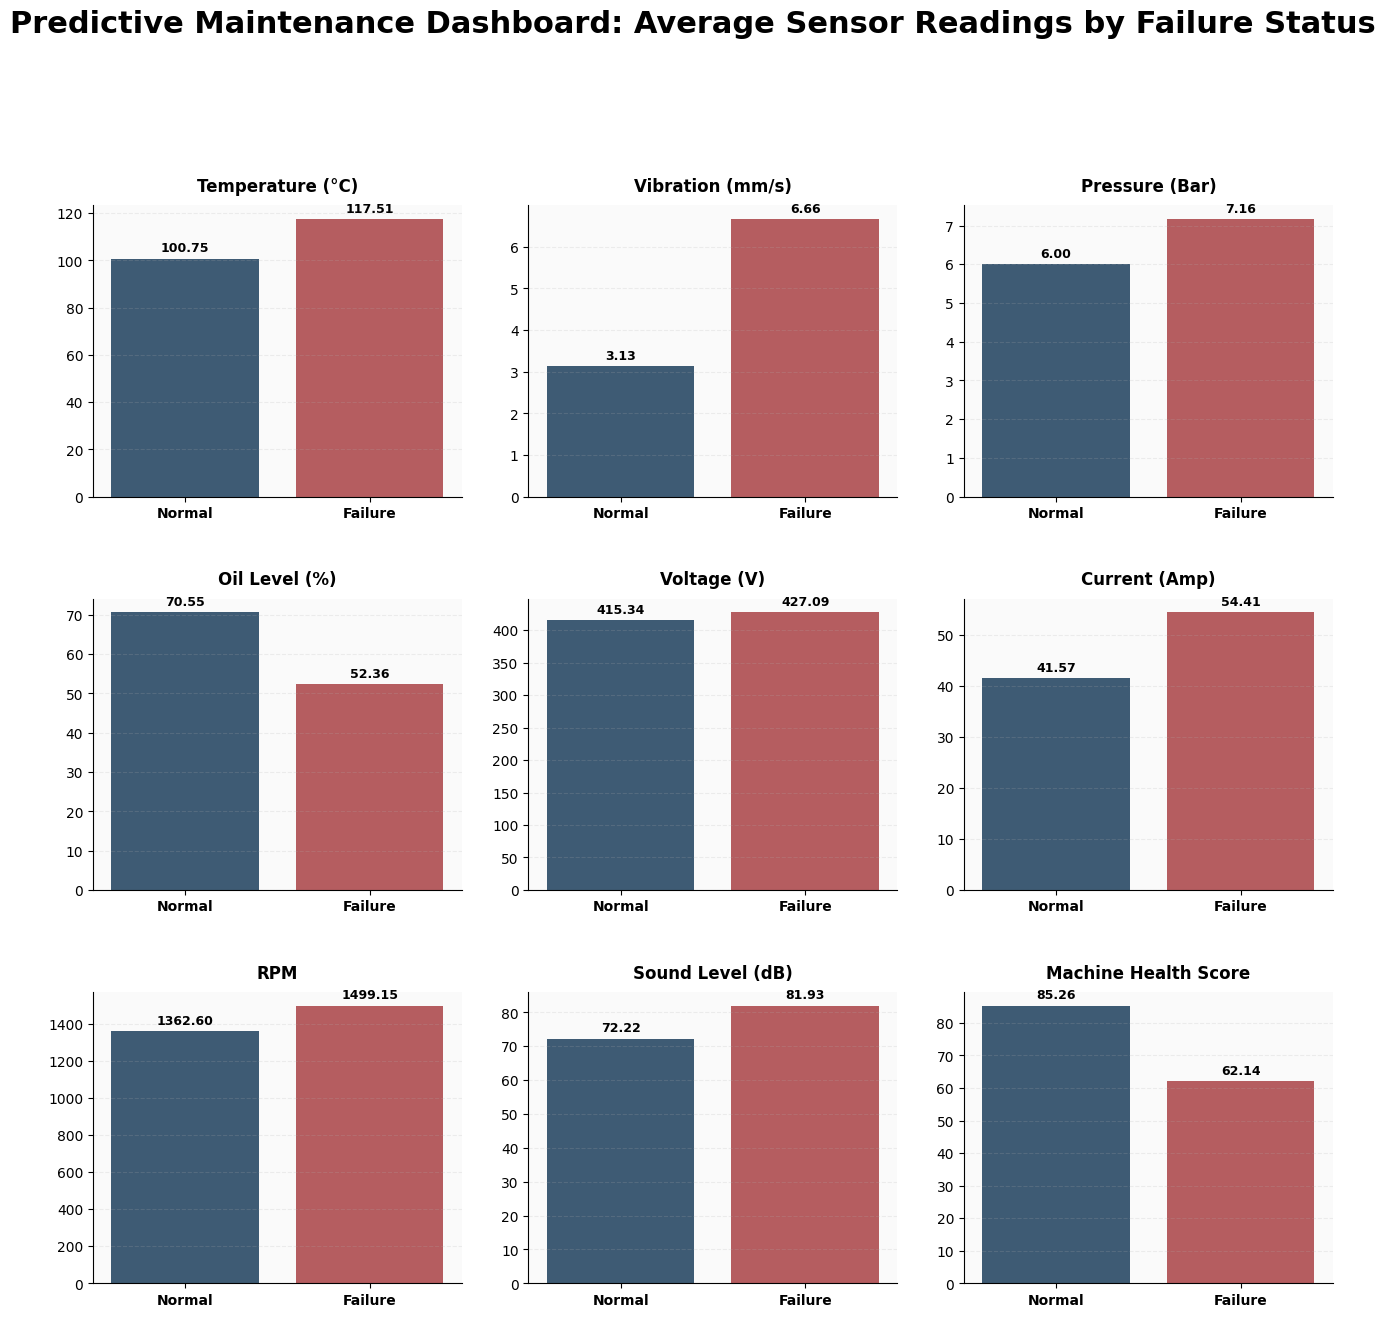

In [54]:


sensor_names = [
    "temperature_c",
    "vibration_mm_s",
    "pressure_bar",
    "oil_level_percent",
    "voltage_v",
    "current_amp",
    "rpm",
    "sound_level_db",
    "machine_health_score"
]

titles = [
    "Temperature (°C)",
    "Vibration (mm/s)",
    "Pressure (Bar)",
    "Oil Level (%)",
    "Voltage (V)",
    "Current (Amp)",
    "RPM",
    "Sound Level (dB)",
    "Machine Health Score"
]



fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for ax, sensor, title in zip(axes.flatten(), sensor_names, titles):

    sns.barplot(
        data=sensor_data,
        x="failure_within_7_days",
        y=sensor,
        hue="failure_within_7_days",
        estimator="mean",
        errorbar=None,
        palette = ["#355C7D", "#C44E52"],
        legend=False,
        ax=ax
    )

    # Value Labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            fontsize=9,
            fontweight="bold",
            padding=3
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        ["Normal", "Failure"],
        fontsize=10,
        fontweight="bold"
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    # Light background
    ax.set_facecolor("#FAFAFA")

    # Grid
    ax.grid(axis="y", linestyle="--", alpha=0.2)

    sns.despine(ax=ax)

plt.suptitle(
    "Predictive Maintenance Dashboard: Average Sensor Readings by Failure Status",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.subplots_adjust(
    hspace=0.35,
    wspace=0.18
)

plt.show()

## Business Insight

### The dashboard reveals clear differences in sensor behavior between machines that continued normal operation and those that failed within seven days. Machines approaching failure generally exhibited higher temperature, vibration, pressure, current, RPM, and sound levels, while oil level and machine health score were noticeably lower. Among all sensor readings, vibration, machine health score, temperature, and oil level showed the most significant differences, making them valuable indicators for predicting potential equipment failures.

## Business Recommendation

### Implement a predictive maintenance strategy by continuously monitoring critical sensor readings such as vibration, temperature, oil level, and machine health score. Configure automated alert thresholds and schedule maintenance when abnormal sensor patterns are detected. Using these indicators proactively can reduce unplanned downtime, improve equipment reliability, and optimize maintenance planning.

In [55]:
query = """SELECT
    downtime_cause,
    ROUND(SUM(estimated_loss_inr) / 1000000, 2) AS Total_Loss_Million
FROM downtime_events
GROUP BY downtime_cause
ORDER BY Total_Loss_Million DESC;"""

downtime_loss = pd.read_sql(query,engine)
downtime_loss

,downtime_cause,Total_Loss_Million
0,Machine Breakdown,2362.63
1,Material Shortage,279.07
2,Power Failure,272.91
3,Quality Hold,272.84
4,Planned Maintenance,270.55
5,Tool Change,266.25
6,Changeover,258.35


C:\Users\gunnu\AppData\Local\Temp\ipykernel_19744\2722514841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


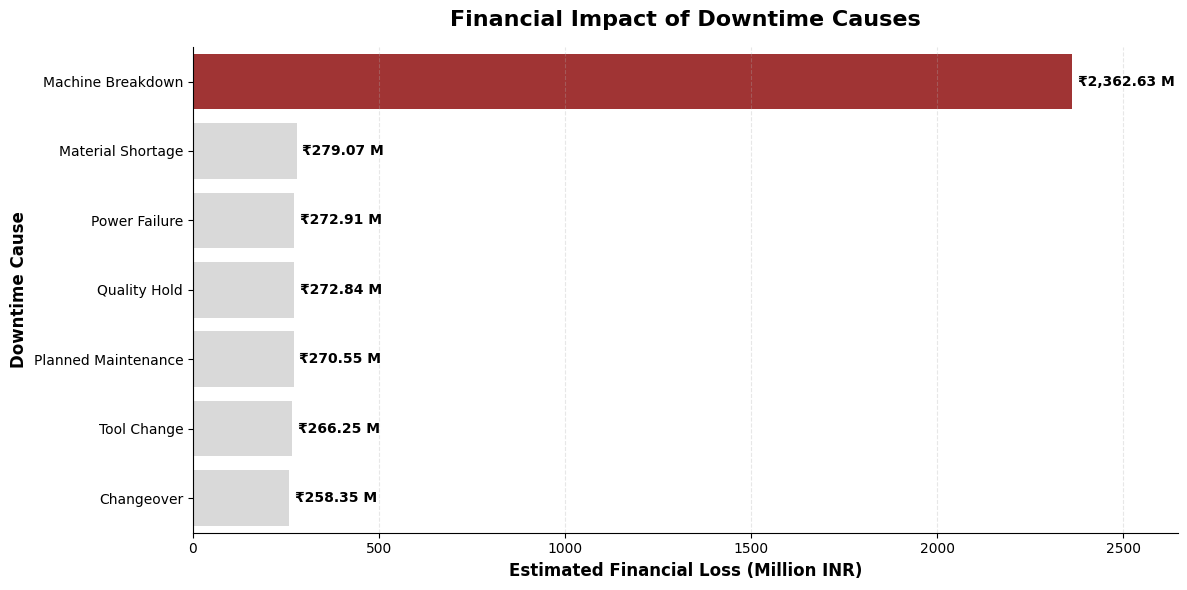

In [56]:
plt.figure(figsize=(12,6))

colors = ["#B22222"] + ["#D9D9D9"] * (len(downtime_loss) - 1)

sns.barplot(
    data=downtime_loss,
    y="downtime_cause",
    x="Total_Loss_Million",
    palette=colors
)



for i, value in enumerate(downtime_loss["Total_Loss_Million"]):
    plt.text(
        value + 15,
        i,
        f"₹{value:,.2f} M",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Financial Impact of Downtime Causes",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Estimated Financial Loss (Million INR)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Downtime Cause",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.xlim(0, downtime_loss["Total_Loss_Million"].max() * 1.12)

plt.tight_layout()
plt.show()

## Business Insight

### Machine Breakdown is the dominant source of downtime-related financial loss, contributing approximately ₹2,362.63 million, which is more than eight times higher than any other downtime cause. All remaining causes—including Material Shortage, Power Failure, Quality Hold, Planned Maintenance, Tool Change, and Changeover—each contribute less than ₹300 million. This indicates that unexpected equipment failures have the greatest financial impact on manufacturing operations.

## Business Recommendation

### Prioritize initiatives that reduce machine breakdowns through predictive maintenance, continuous machine condition monitoring, and timely replacement of worn components. Since machine breakdowns account for the majority of downtime losses, even a modest reduction in these events could generate substantial cost savings and improve production continuity.

In [57]:
query = """SELECT
    m.machine_type,
    ROUND(SUM(d.estimated_loss_inr)/1000000,2) AS Downtime_Loss_Million
FROM downtime_events d
JOIN machines m
ON d.machine_id = m.machine_id
GROUP BY m.machine_type
ORDER BY Downtime_Loss_Million DESC;"""

pd.read_sql(query,engine)

,machine_type,Downtime_Loss_Million
0,Industrial Furnace,598.53
1,Packaging Line,581.12
2,Grinding Machine,514.81
3,CNC Lathe,501.11
4,Hydraulic Press,480.63
5,CNC Milling,461.02
6,Injection Molding,453.06
7,Assembly Robot,392.31


In [58]:
query = """SELECT
    f.factory_name,
    ROUND(SUM(d.duration_hours),2) AS Total_Downtime_Hours
FROM downtime_events d
JOIN factories f
ON d.factory_id = f.factory_id
GROUP BY f.factory_name
ORDER BY Total_Downtime_Hours DESC;"""

pd.read_sql(query,engine)

,factory_name,Total_Downtime_Hours
0,Chennai Manufacturing Plant,4766.66
1,Kolkata Manufacturing Plant,4617.16
2,Gurugram Manufacturing Plant,4562.23
3,Bengaluru Manufacturing Plant,4480.44
4,Pune Manufacturing Plant,4456.93
5,Ahmedabad Manufacturing Plant,4369.15
6,Indore Manufacturing Plant,4088.09
7,Hyderabad Manufacturing Plant,3961.61
8,Noida Manufacturing Plant,3441.58
9,Jamshedpur Manufacturing Plant,3344.28


In [59]:
query = """SELECT
    impact_level,
    COUNT(*) AS Total_Events,
    ROUND(SUM(estimated_loss_inr)/1000000,2) AS Loss_Million
FROM downtime_events
GROUP BY impact_level;"""

pd.read_sql(query,engine)

,impact_level,Total_Events,Loss_Million
0,Medium,3278,1660.86
1,High,2537,1247.23
2,Low,1204,577.79
3,Critical,981,496.72


In [60]:
query = """SELECT
    p.product_name,
    ROUND(
        SUM(pb.defective_units)*100.0 /
        SUM(pb.units_produced),
        2
    ) AS Defect_Percentage
FROM production_batches pb
JOIN products p
ON pb.product_id = p.product_id
GROUP BY p.product_name
ORDER BY Defect_Percentage DESC
LIMIT 10;"""

pd.read_sql(query,engine)

,product_name,Defect_Percentage
0,Plastic Component 065,10.53
1,Plastic Component 068,10.53
2,Mechanical Part 019,10.48
3,Automotive Part 090,10.33
4,Mechanical Part 140,10.05
5,Mechanical Part 062,9.99
6,Plastic Component 067,9.95
7,Plastic Component 097,9.83
8,Mechanical Part 105,9.77
9,Automotive Part 124,9.51


# Executive Summary
---
## Project Overview

## This project analyzes manufacturing operations by integrating production, quality, maintenance, machine performance, sensor data, supplier information, and downtime events. The objective is to identify operational inefficiencies, improve product quality, reduce downtime, and support predictive maintenance through data-driven insights.
---
## Key Business Findings
- Manufacturing plants showed significant differences in production volume and machine failure frequency, highlighting opportunities for targeted operational improvements.
- Night Shift recorded the highest defect percentage, indicating the need for additional quality monitoring during night operations.
- Several operators consistently achieved product quality above 93%, demonstrating strong operational performance and adherence to manufacturing standards.
- Plastic Component 068 generated the highest scrap cost, making it the highest-priority product for waste reduction initiatives.
- Industrial Furnaces required the highest maintenance effort and also incurred the highest average maintenance cost among all machine types.
- A small group of machines experienced both frequent failures and repeated maintenance activities, making them ideal candidates for proactive maintenance.
- Machine breakdowns accounted for the largest share of downtime-related financial losses, far exceeding all other downtime causes.
- Machines that failed within seven days consistently showed higher temperature, vibration, pressure, current, RPM, and sound levels, while oil level and machine health score declined significantly, demonstrating strong indicators for predictive maintenance.
- Products with the highest defect percentages should be prioritized for process optimization and quality improvement initiatives.
---
# Business Recommendations
- Implement predictive maintenance by continuously monitoring critical sensor readings such as temperature, vibration, oil level, and machine health score.
- Prioritize high-risk machines for root cause analysis and preventive servicing to reduce recurring failures.
- Focus on reducing machine breakdowns, as they represent the largest source of downtime-related financial losses.
- Improve quality control procedures during the Night Shift to reduce defect rates and manufacturing waste.
- Investigate products with high scrap costs and defect percentages by reviewing raw materials, machine settings, and production processes.
- Strengthen maintenance planning for Industrial Furnaces and other high-maintenance equipment to improve reliability and reduce long-term maintenance costs.
- Use supplier and production performance insights to support continuous improvement initiatives and optimize manufacturing operations.